# Overview

This script does .... [place holder]

## Running to do list

1. for merged_df - check if any of the values between plopp/flopp have non-null values for spectra? answers question are the wavenlength values exclusive between targets? 
2. If yes, perhaps there is a better way to export using a python package for .spas? 
3. 





In [25]:
import os
import sys
import pandas as pd
import xgboost as xgb
import numpy as np
from xgboost import plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.svm import SVC


from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


# increase the decimal places in all columns 
pd.options.display.float_format = '{:.6f}'.format

# 1. Load Data and Preprocess

We first combine the separate FLOPP and PLOPP datasets; add target columsn, and then merge into our training dataset. 

**PLOPP**: Currently there are 936 columns and 237 rows, representing 237 individual spectra (?) from individual csv files. 

**FLOPP**: Currently there are x columns and y rows, representing z individual spectra (?) from individual csv files. 

## to do list: 
1. data merging - disregard SPA files 
2. cut from PLOPP list (remove names/csvs)
4/24/24: use the 

## PLOPP

In [26]:
# Combine all the CSVs into one merged PLOPP dataset

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        if filename.lower().endswith('.csv'):  
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df

directory = "../../../../CSV Files/PLOPP/CSV Files"




plopp_df = process_csv_files(directory)

plopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in plopp_df.columns]

plopp_df['Target'] = "PLOPP"

plopp_df.to_csv("../../../../CSV Files/PLOPP/plopp_merged.csv", index=False)



# Print the master DataFrame for review
plopp_df
print(plopp_df.shape)



(263, 938)


In [27]:
plopp_df.head()

,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.817920,91.799890,91.768400,91.759260,91.803400,91.885330,91.895230,0.000000,54c.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.245870,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000,23a.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.535050,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000,74a.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.119210,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000,78b.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLOPP


## FLOPP

In [28]:
directory = "../../../../CSV Files/FLOPP/8 cm -1 resolution CORRECT"

flopp_df = process_csv_files(directory)
flopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in flopp_df.columns]

flopp_df['Target'] = "FLOPP"

#flopp_df.to_csv("../../CSV Files/FLOPP/Flopp_merged.csv", index=False)


print(flopp_df.shape)
# Print the master DataFrame for review
flopp_df


(186, 938)


,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLOPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.188320,99.233940,99.190930,99.225070,99.156200,99.293390,99.180210,0.000000,PEVA 10_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.601630,97.646840,97.662280,97.705030,97.718460,97.702880,97.682560,0.000000,Polyester 10_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.619910,99.624230,99.595730,99.585510,99.593260,99.630400,99.604730,0.000000,PLA 9_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.648720,99.642620,99.626400,99.630580,99.635880,99.643420,99.582090,0.000000,PU 6_8 cm.CSV,FLOPP


## Merging


In [29]:
flopps_cols = flopp_df.columns
plopp_cols = plopp_df.columns

# print out the column elements

merged_cols = [i for i in plopp_cols if i in flopps_cols]

In [30]:
result_df = pd.concat([flopp_df, plopp_df], axis=0, ignore_index=True)


In [31]:
result_df

,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLOPP
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLOPP
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLOPP
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLOPP
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLOPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.000130,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLOPP
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.101600,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLOPP
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.348060,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLOPP
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.008270,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLOPP


In [23]:
result_df.to_csv("../../data/output/merged_df.csv")

# Hyperparameter Tuning

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from scipy.signal import savgol_filter
import numpy as np
import pandas as pd
import json

# Define the data transformation functions
def standard_normal_variate(X):
    mean_centered = X - np.mean(X, axis=1, keepdims=True)
    snv_transformed = mean_centered / np.std(mean_centered, axis=1, keepdims=True)
    return snv_transformed

def calculate_derivatives(data, window_length, polyorder, deriv=1):
    return savgol_filter(data, window_length, polyorder, deriv=deriv)

class SNVTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        mean_centered = X - np.mean(X, axis=1, keepdims=True)
        if self.use_scaling:
            return mean_centered / np.std(mean_centered, axis=1, keepdims=True)
        return mean_centered

class DerivativeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=11, polyorder=2, deriv=1):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        transformed = np.apply_along_axis(calculate_derivatives, axis=1, arr=X,
                                          window_length=self.window_length, 
                                          polyorder=self.polyorder, deriv=self.deriv)
        return transformed


result_df['Target'] = result_df['Target'].map({'FLOPP': 0, 'PLOPP': 1})
features = result_df.drop(['Target', 'Sample'], axis=1)
target = result_df['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

# Models to be evaluated
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'XGBoost': XGBClassifier()
}

best_model_name = None
best_f1_score = 0
best_params = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('snv', SNVTransformer()),
        ('derivatives', DerivativeTransformer()),
        ('classifier', model)
    ])
    
    param_grid = {
        'snv__use_scaling': [True, False],
        'derivatives__deriv': [0, 1, 2]
    }

    if name == 'XGBoost':
        param_grid.update({
            'classifier__n_estimators': [100, 500],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__max_depth': [3, 6, 9]
        })

    if name == "Random Forest":
        param_grid.update({
            'classifier__n_estimators': [100, 200, 300, 500],
            'classifier__max_depth': [3, 6, 9],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__max_features': ['auto', 'sqrt', 'log2']
        })

    if name == "Logistic Regression":
        param_grid.update({
            'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
        })

    if name == "SVM":
        param_grid.update({
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            'classifier__gamma': ['scale', 'auto']
        })

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', verbose=1)
    
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters for {name}:", grid_search.best_params_)
    print(f"Best cross-validation score (F1) for {name}: {grid_search.best_score_:.3f}")
    
    if grid_search.best_score_ > best_f1_score:
        best_f1_score = grid_search.best_score_
        best_model_name = name
        best_params = grid_search.best_params_

with open('best_params.json', 'w') as f:
    json.dump(best_params, f)

print(f"The best model is {best_model_name} with a cross-validation F1 score of {best_f1_score:.3f}")


Training data shape: (269, 936)
Testing data shape: (180, 936)
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits


/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
3240 fits failed out of a total of 9720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/base.

Best parameters for Random Forest: {'classifier__max_depth': 6, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'derivatives__deriv': 1, 'snv__use_scaling': False}
Best cross-validation score (F1) for Random Forest: 0.994
Fitting 5 folds for each of 600 candidates, totalling 3000 fits


/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ di

Best parameters for Logistic Regression: {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear', 'derivatives__deriv': 1, 'snv__use_scaling': False}
Best cross-validation score (F1) for Logistic Regression: 0.988
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters for SVM: {'classifier__C': 100, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly', 'derivatives__deriv': 2, 'snv__use_scaling': True}
Best cross-validation score (F1) for SVM: 0.986
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for XGBoost: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}
Best cross-validation score (F1) for XGBoost: 0.979
The best model is Random Forest with a cross-validation F1 score of 0.994


In [ ]:
# best_params = {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}

In [ ]:
best_params

{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 100,
 'derivatives__deriv': 1,
 'snv__use_scaling': True}

# Model Training and Evaluation

In [ ]:
result_df = pd.read_csv("../../data/output/merged_df.csv")
result_df = result_df.drop(['Unnamed: 0'], axis=1)
result_df

,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLOPP
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLOPP
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLOPP
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLOPP
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLOPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.000130,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLOPP
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.101600,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLOPP
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.348060,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLOPP
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.008270,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLOPP


Training data shape: (269, 936)
Testing data shape: (180, 936)

Random Forest Model Evaluation:
Accuracy: 0.9944444444444445
Precision: 0.9900990099009901
Recall: 1.0
F1 Score: 0.9950248756218906

Logistic Regression Model Evaluation:
Accuracy: 0.9611111111111111
Precision: 0.9345794392523364
Recall: 1.0
F1 Score: 0.966183574879227


/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [19:12:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "classifier__learning_rate", "classifier__max_depth", "classifier__n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [19:12:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)



XGBoost Model Evaluation:
Accuracy: 0.9833333333333333
Precision: 0.9801980198019802
Recall: 0.99
F1 Score: 0.9850746268656716


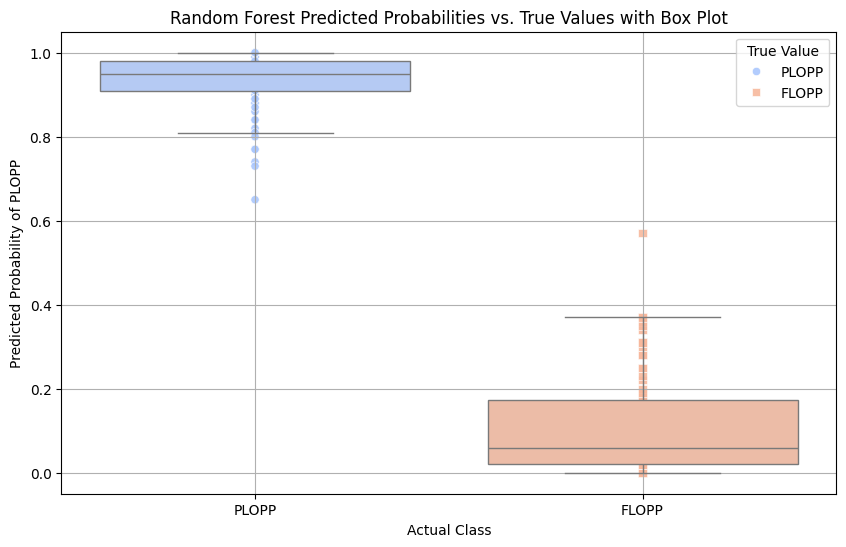

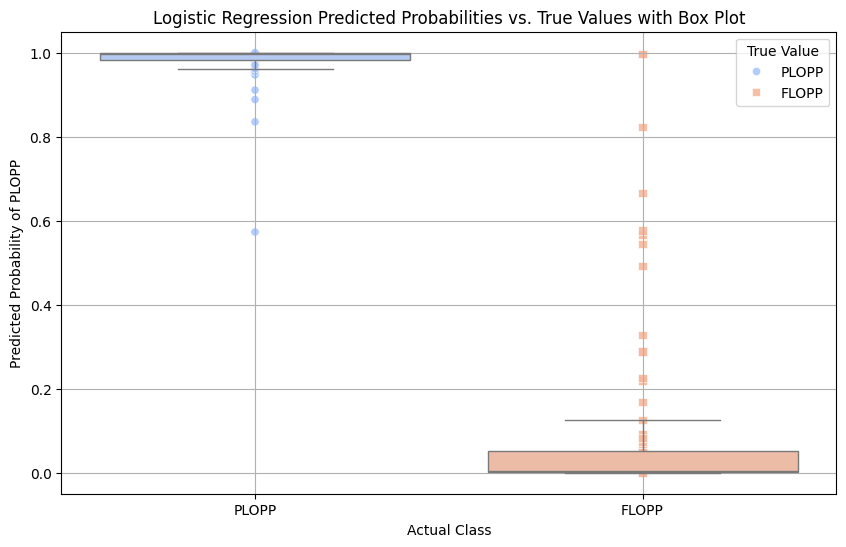

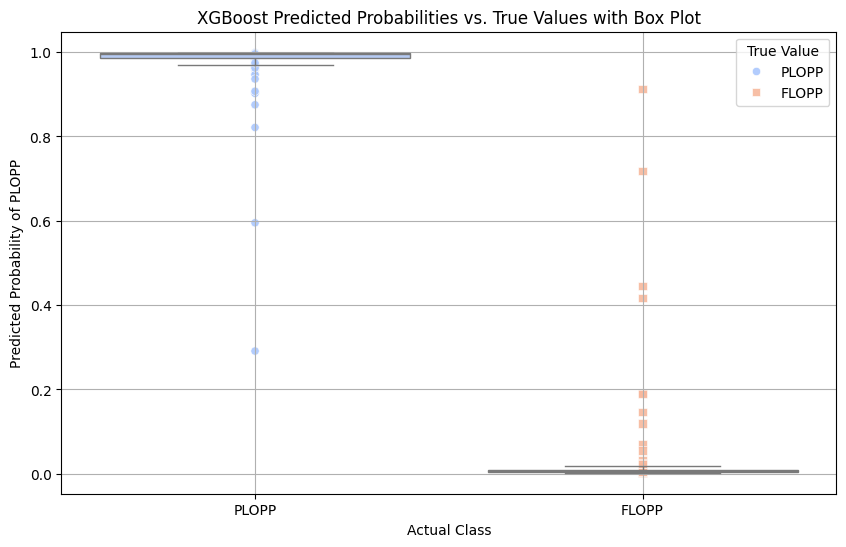

In [ ]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from scipy.signal import savgol_filter

# Load the data
#result_df = pd.read_csv("../../data/output/merged_df.csv", ignore_index=True)

# Example data transformation functions
def standard_normal_variate(X):
    mean_centered = X - np.mean(X, axis=1, keepdims=True)
    snv_transformed = mean_centered / np.std(mean_centered, axis=1, keepdims=True)
    return snv_transformed

def calculate_derivatives(data, window_length, polyorder, deriv=1):
    return savgol_filter(data, window_length, polyorder, deriv=deriv)

class SNVTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        mean_centered = X - np.mean(X, axis=1, keepdims=True)
        if self.use_scaling:
            return mean_centered / np.std(mean_centered, axis=1, keepdims=True)
        return mean_centered

class DerivativeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=11, polyorder=2, deriv=1):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        transformed = np.apply_along_axis(calculate_derivatives, axis=1, arr=X,
                                          window_length=self.window_length, 
                                          polyorder=self.polyorder, deriv=self.deriv)
        return transformed

# Assuming result_df contains the data
result_df['Target'] = result_df['Target'].map({'FLOPP': 0, 'PLOPP': 1})
features = result_df.drop(['Target', 'Sample'], axis=1)
target = result_df['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

# Best parameters for each model
best_params = {
    'Random Forest': {'derivatives__deriv': 1, 'snv__use_scaling': True},
    'Logistic Regression': {'derivatives__deriv': 1, 'snv__use_scaling': False},
    'XGBoost': {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}
}

# Models to be evaluated
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'XGBoost': XGBClassifier()
}

for name, model in models.items():
    params = best_params[name]
    snv_use_scaling = params.pop('snv__use_scaling')
    derivatives_deriv = params.pop('derivatives__deriv')
    
    pipeline = Pipeline([
        ('snv', SNVTransformer(use_scaling=snv_use_scaling)),
        ('derivatives', DerivativeTransformer(deriv=derivatives_deriv)),
        ('classifier', model.set_params(**params))
    ])
    
    # Train the model with best parameters
    pipeline.fit(X_train, y_train)
    

    if name == 'XGBoost':
        pipeline.named_steps['classifier'].save_model(f'../models/{name}.model')
    elif name == 'Random Forest':
        with open(f'../models/{name}_model.pkl', 'wb') as f:
            pickle.dump(pipeline.named_steps['classifier'], f)
    
    
    # Predict the test set results
    y_pred = pipeline.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{name} Model Evaluation:")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='g', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name} Confusion Matrix')
    plt.savefig(f'../figures/{name}_confusion_matrix.png')
    plt.close(fig)
    
    # ROC Curve
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots()
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} Receiver Operating Characteristic')
    ax.legend(loc="lower right")
    plt.savefig(f'../figures/{name}_roc_curve.png')
    plt.close(fig)
    
    # Feature Importance (Method 1) - Only for models that provide feature importances
    if name in ['Random Forest', 'XGBoost']:
       
        feature_importances = pipeline.named_steps['classifier'].feature_importances_
        feature_names = features.columns
        importances_series = pd.Series(feature_importances, index=feature_names)
        top_ten_importances = importances_series.sort_values(ascending=True)[-25:]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        top_ten_importances.plot(kind='barh', ax=ax)
        ax.set_title(f'{name} Top 25 Feature Importance')
        ax.set_ylabel("Importance")
        ax.set_xlabel("Features")
        
        # save the feature importances as a png
        plt.savefig(f'../figures/{name}_feature_importances.png')
        plt.close(fig)


        # explainer = shap.Explainer(pipeline.named_steps['classifier'], X_train)
        # shap_values = explainer(X_train)
        # fig, ax = plt.subplots(figsize=(10, 8))
       # print(shap_values  )
        #shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
        #plt.title(f'{name} SHAP Summary Plot')
       # plt.savefig(f'../figures/{name}_shap_summary.png')
        


    # Predicted Probabilities Plot
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    plot_data = pd.DataFrame({
        'Predicted Probability': y_pred_proba,
        'Actual Class': y_test
    })
    
    # Convert 'Actual Class' to a categorical type and rename categories
    plot_data['Actual Class'] = pd.Categorical(plot_data['Actual Class'])
    plot_data['Actual Class'] = plot_data['Actual Class'].cat.rename_categories({0: 'FLOPP', 1: 'PLOPP'})
    plot_data['True Value'] = np.where(plot_data['Actual Class'] == 'FLOPP', 'FLOPP', 'PLOPP')
    
    plt.figure(figsize=(10, 6))
    
    # Create a horizontal scatter plot
    sns.scatterplot(data=plot_data, y='Predicted Probability', x='True Value', hue='True Value', palette='coolwarm', style='True Value', markers=['o', 's'], alpha=0.9)
    
    # Create a horizontal boxplot overlay
    sns.boxplot(data=plot_data, y='Predicted Probability', x='True Value', hue='True Value', palette='coolwarm', whis=1.5, fliersize=0)
    
    # Customize the plot
    plt.title(f'{name} Predicted Probabilities vs. True Values with Box Plot')
    plt.ylabel('Predicted Probability of PLOPP')
    plt.xlabel('Actual Class')
    plt.grid(True)
    plt.savefig(f'../figures/{name}_predicted_probs_box.png')
    plt.close(fig)


### Shap Values

In [ ]:
# import xgboost as xgb
# import shap
# import joblib
# import matplotlib.pyplot as plt

# # Load the XGBClassifier model
# model = xgb.XGBClassifier()
# model.load_model("../models/XGBoost.model")

# # Create SHAP explainer and calculate SHAP values
# explainer = shap.Explainer(model)
# shap_values = explainer(X_train)

# # Set a name for the plot
# name = "XGBoost"  # You can change this to any name you want

# # Create SHAP summary plot
# fig, ax = plt.subplots(figsize=(10, 10))
# shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)

# # Add a custom title using fig.suptitle
# fig.suptitle(f'{name} SHAP Summary Plot', fontsize=16)

# # Save the figure
# plt.savefig(f'../figures/{name}_shap_summary.png')

# # Show the plot
# plt.show()



# # Load the random forest pickle
# with open("/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/analysis/models/Random Forest_model.pkl", "rb") as f:
#     model = pickle.load(f)
     
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_train)

# # Set a name for the plot
# name = "Random Forest"  # You can change this to any name you want

# # Create SHAP summary plot
# fig, ax = plt.subplots()
# shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)

# # Add a custom title using fig.suptitle
# fig.suptitle(f'{name} SHAP Summary Plot', fontsize=16)

# # Save the figure
# plt.savefig(f'../figures/{name}_shap_summary.png')

# # Show the plot
# plt.show()

